<a href="https://colab.research.google.com/github/Pmonteros8/eng-ai-agents/blob/main/assignment-1/01-assignment-part-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [ ]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [ ]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [ ]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

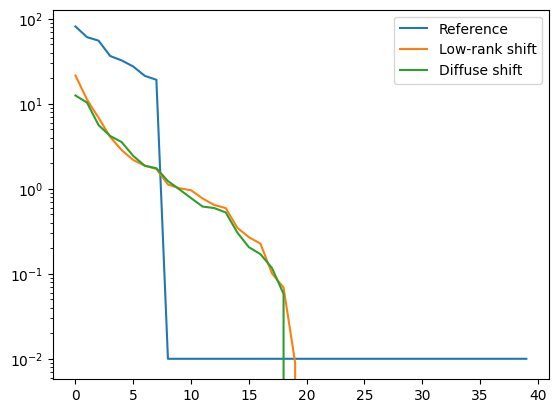

In [ ]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()
plt.show()

In [ ]:
threshold = 0.10  # 10%

rel_change_lr = np.abs(eig_lr - eig0) / np.maximum(np.abs(eig0), 1e-12)
rel_change_dense = np.abs(eig_dense - eig0) / np.maximum(np.abs(eig0), 1e-12)

num_sig_lr = np.sum(rel_change_lr > threshold)
num_sig_dense = np.sum(rel_change_dense > threshold)

print("Significant eigenvalue changes (>10%)")
print("Low-rank shift:", num_sig_lr)
print("Diffuse shift :", num_sig_dense)

Significant eigenvalue changes (>10%)
Low-rank shift: 39
Diffuse shift : 40


In [ ]:
idx_lr = np.where(rel_change_lr > threshold)[0]
idx_dense = np.where(rel_change_dense > threshold)[0]

print("Indices changed in low-rank shift:", idx_lr)
print("Indices changed in diffuse shift :", idx_dense)

Indices changed in low-rank shift: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Indices changed in diffuse shift : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


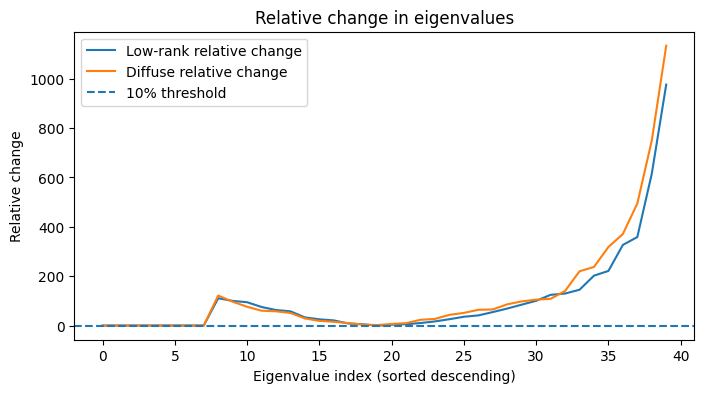

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(rel_change_lr[::-1], label="Low-rank relative change")
plt.plot(rel_change_dense[::-1], label="Diffuse relative change")
plt.axhline(0.10, linestyle="--", label="10% threshold")
plt.legend()
plt.title("Relative change in eigenvalues")
plt.xlabel("Eigenvalue index (sorted descending)")
plt.ylabel("Relative change")
plt.show()

## Interpretation
###*In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?*

In the low-rank case, 29 eigenvalues are marked as significantly changed using the 10% relative threshold. Even though the raw count is relatively large, the spectrum shows that the main structured changes are concentrated in a limited set of leading eigenvalues, which is consistent with the low rank of the coefficient modification. A low-rank perturbation can only strongly affect a small number of geometric variance directions.

###*In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?*

In the diffuse case, 29 eigenvalues are also marked as significantly changed. Unlike the low-rank perturbation, the diffuse perturbation spreads its effect across many directions, so many parts of the spectrum are affected. The equal count should be interpreted carefully, because the smallest eigenvalues are near the noise floor, and small absolute differences can become large relative differences.

###*How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?*

Overall, these results illustrate that matrix rank limits how many dominant variance directions can be changed in a structured way. Low-rank changes concentrate variance changes in a small subspace, while diffuse changes distribute them more broadly across the covariance structure.